# STAC integration

This tutorial shows how to build a lazy `RasterData` from a **STAC**
catalogue with `RasterData.from_stac`, using the
[EcoDataCube](https://stac.opengeohub.org/v1/cat/ecodatacube) catalogue
(67 European variables, EPSG:3035, 30 m).  The result holds remote COG
hrefs + dates only, so we sample it with `SpaceTimeOverlay` (point
queries) and read a small tile — never the full continental grid.


In [1]:
import os

os.environ["PROJ_LIB"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"
os.environ["PROJ_DATA"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"


In [2]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from skmap.io import RasterData
from skmap.data import toy
from skmap.overlay import SpaceTimeOverlay


## Loading layers from the STAC catalogue

`from_stac` queries the per-collection `/items` endpoint and returns a
**lazy** `RasterData`: one `info` row per data asset, with `collection`,
`asset`, `year`, `gsd` and `epsg` columns.  The `datetime` window is
filtered client-side.


In [3]:
rdata = RasterData.from_stac(
    url="https://stac.opengeohub.org/v1/cat/ecodatacube",
    collections="ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube",
    datetime="2019-01-01/2019-12-31",
)
rdata


In [4]:
rdata.info[["group", "name", "start_date", "end_date", "collection", "asset", "year", "epsg", "gsd"]]


,group,name,start_date,end_date,collection,asset,year,epsg,gsd
0,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s_1101,2019-11-01,2019-12-31,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s,2019,3035,30.0
1,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0901,2019-09-01,2019-10-31,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s,2019,3035,30.0
2,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0701,2019-07-01,2019-08-31,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s,2019,3035,30.0
3,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0501,2019-05-01,2019-06-30,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s,2019,3035,30.0
4,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0301,2019-03-01,2019-04-30,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s,2019,3035,30.0
5,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0101,2019-01-01,2019-02-28,ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube,ndvi_glad.landsat.ard2.seasconv_m_30m_s,2019,3035,30.0


In [5]:
rdata.get_groups()


['ndvi_glad.landsat.ard2.seasconv_eu_ecodatacube']

## Space-time overlay with toy reference samples

The bundled `toy.lc_samples()` are already in **EPSG:3035** — the same CRS
as the ecodatacube layers — so we can overlay them directly, sampling the
remote COGs at the point locations without loading whole rasters.


In [6]:
samples = toy.lc_samples()
samples = samples[samples["date"].dt.year == 2019]

overlay = SpaceTimeOverlay(
    points=samples,
    col_date="date",
    rasterdata=rdata,
    date_ranges=[("2019-01-01", "2019-12-31")],
    raster_tiles=None,
    verbose=False,
)
train = overlay.run(max_ram_mb=512, out_file_name=None)


Dropping 0 points out of 38 because out of extent


In [7]:
train.head()


,date,label,code,target,lon,lat,ndvi_glad.landsat.ard2.seasconv_m_30m_s_1101,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0901,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0701,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0501,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0301,ndvi_glad.landsat.ard2.seasconv_m_30m_s_0101
0,2019-01-01,Non-irrigated arable land,211,12,4.027366e+06,3.213354e+06,171.0,200.0,188.0,216.0,211.0,195.0
1,2019-01-01,Non-irrigated arable land,211,12,4.023032e+06,3.217703e+06,197.0,215.0,185.0,185.0,190.0,204.0
2,2019-01-01,Pastures,231,18,4.025421e+06,3.210923e+06,200.0,213.0,210.0,207.0,204.0,182.0
3,2019-01-01,Road and rail networks and associated land,122,4,4.027810e+06,3.215667e+06,182.0,185.0,184.0,179.0,182.0,183.0
4,2019-01-01,Pastures,231,18,4.026862e+06,3.213664e+06,200.0,214.0,208.0,214.0,221.0,202.0


## Reading a small tile and plotting

`read(extent=...)` reads only a bounding box (here the samples' AOI in
EPSG:3035), and `plot` renders each bimonthly composite with a
`{field}` title template.


2026-08-27 09:48:58,367	WARNING services.py:2248 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-08-27 09:49:01,594	INFO worker.py:2024 -- Started a local Ray instance.


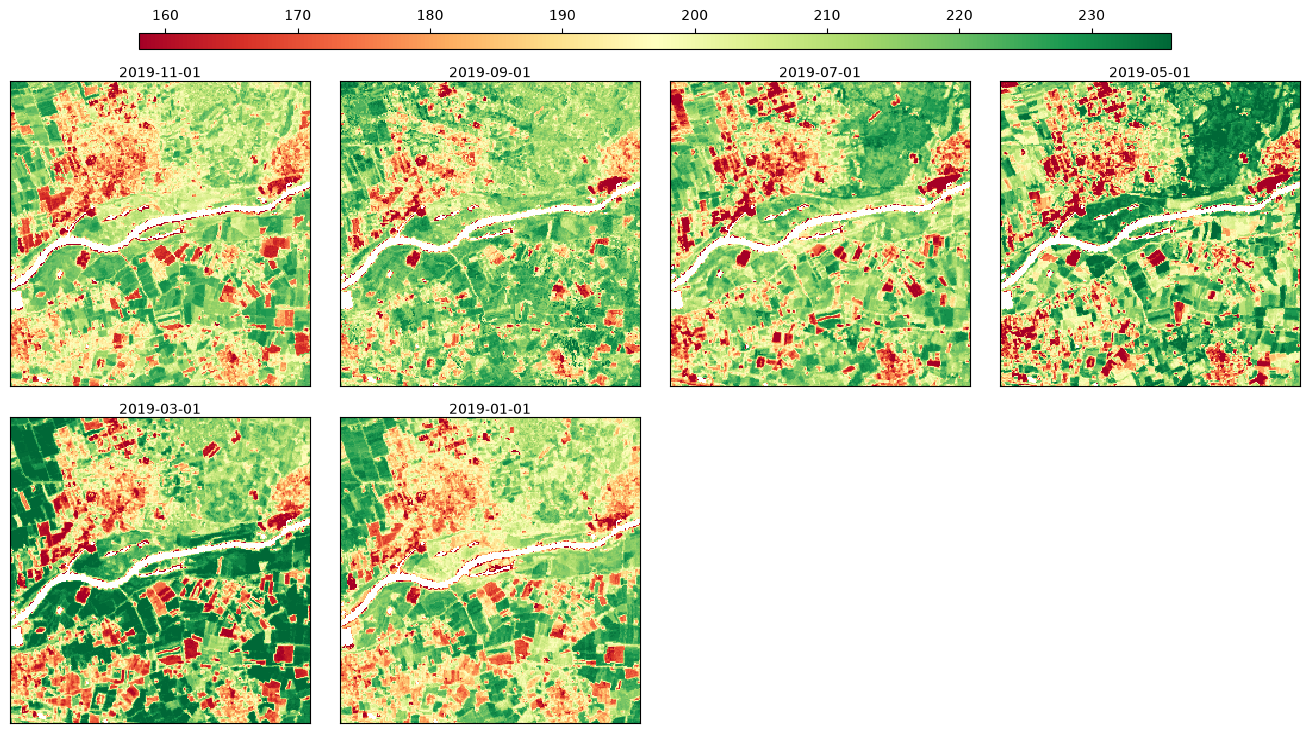

In [8]:
tile = rdata.read(extent=[4020674, 3210142, 4028246, 3217730], extent_epsg=3035)
tile.plot(cmap="RdYlGn", img_title_text="{start_date:%Y-%m-%d}")
